In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import pickle
import shutil
import boto3
from tqdm import tqdm
import sys
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import xmltodict
except:
    ! pip install xmltodict

try:
    import optbinning
except:
    ! pip install optbinning

# silence warnings
import warnings
warnings.filterwarnings('ignore')

(CVXPY) Dec 16 09:14:00 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Dec 16 09:14:00 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2024-12-16 21:14:00.413518


#### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [4]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [5]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# factor 24 to 72
flt_factor_24_to_72 = 2.36

Project: 20241112-simple-model-test
Task: 09_15_in_60
Subtask: 10_swap_in_swap_out


#### Make output directory

In [6]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import scorecard predictions

In [7]:
list_cols = [
    'accountid',
    'yhat_ml_logistic_scorecard',
]
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../03_get_predictions/output/{str_filename}'
df_gen13 = pd.read_parquet(
    str_local_path,
    columns=list_cols,
)
# rename
dict_rename = {
    'yhat_ml_logistic_scorecard': 'pd_gen13'
}
df_gen13.rename(columns=dict_rename, inplace=True)
# show
df_gen13

,accountid,pd_gen13
0,8211697,0.116122
1,8315912,0.111542
2,8323560,0.171425
3,8332159,0.305018
4,8337838,0.143952
...,...,...
995,8472730,0.182745
996,8472731,0.231619
997,8472750,0.170825
998,8472773,0.262573


#### Load parser for interpolation

In [8]:
# api
str_filename = 'api.py'
str_origin = f'../06_parser/{str_filename}'
str_destination = f'./{str_filename}'
shutil.copyfile(str_origin, str_destination)

# preprocessing
str_filename = 'preprocessing.py'
str_origin = f'../06_parser/{str_filename}'
str_destination = f'./{str_filename}'
shutil.copyfile(str_origin, str_destination)

# counters
str_filename = 'functions_counters.py'
str_origin = f'../06_parser/{str_filename}'
str_destination = f'./{str_filename}'
shutil.copyfile(str_origin, str_destination)

# pricing
str_filename = 'functions_counters_pricing.py'
str_origin = f'../06_parser/{str_filename}'
str_destination = f'./{str_filename}'
shutil.copyfile(str_origin, str_destination)

# parser
str_filename = 'cls_parser.pkl'
str_local_path = f'../06_parser/output/{str_filename}'
cls_parser = pickle.load(open(str_local_path, 'rb'))

#### Interpolate

In [9]:
df_gen13['ecnl_gen13'] = list(np.interp(
    x=list(df_gen13['pd_gen13']),
    xp=cls_parser.arr_quantiles_model,
    fp=cls_parser.arr_score_quantiles_pricing,
))
list_cols = [
    'accountid',
    'pd_gen13',
    'ecnl_gen13',
]
df_gen13 = df_gen13[list_cols].copy()
# rm
os.remove('api.py')
os.remove('preprocessing.py')
# show
df_gen13

,accountid,pd_gen13,ecnl_gen13
0,8211697,0.116122,0.175046
1,8315912,0.111542,0.161494
2,8323560,0.171425,0.304637
3,8332159,0.305018,0.650430
4,8337838,0.143952,0.238451
...,...,...,...
995,8472730,0.182745,0.328197
996,8472731,0.231619,0.446615
997,8472750,0.170825,0.303972
998,8472773,0.262573,0.519305


#### Get Gen 12 predictions

In [10]:
list_cols = [
    'accountid',
    'pd',
    'ecnl',
]
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../04_pricing_distribution/output/{str_filename}'
df_gen12 = pd.read_parquet(
    str_local_path,
    columns=list_cols,
)
# rename
dict_rename = {
    'pd': 'pd_gen12',
    'ecnl': 'ecnl_gen12'
}
df_gen12.rename(columns=dict_rename, inplace=True)
# show
df_gen12

,accountid,pd_gen12,ecnl_gen12
0,8211697,0.169426,0.248733
1,8315912,0.030895,0.045663
2,8323560,0.167438,0.276869
3,8332159,0.175550,0.283977
4,8337838,0.045893,0.079110
...,...,...,...
995,8472730,0.255127,0.346713
996,8472731,0.408038,0.612172
997,8472750,0.235176,0.346111
998,8472773,0.349750,0.541301


#### Join

In [11]:
# join
df = pd.merge(
    left=df_gen12,
    right=df_gen13,
    on='accountid',
    how='inner',
)
# save memory
del df_gen12
del df_gen13
# show
df

,accountid,pd_gen12,ecnl_gen12,pd_gen13,ecnl_gen13
0,8211697,0.169426,0.248733,0.116122,0.175046
1,8315912,0.030895,0.045663,0.111542,0.161494
2,8323560,0.167438,0.276869,0.171425,0.304637
3,8332159,0.175550,0.283977,0.305018,0.650430
4,8337838,0.045893,0.079110,0.143952,0.238451
...,...,...,...,...,...
995,8472730,0.255127,0.346713,0.182745,0.328197
996,8472731,0.408038,0.612172,0.231619,0.446615
997,8472750,0.235176,0.346111,0.170825,0.303972
998,8472773,0.349750,0.541301,0.262573,0.519305


#### Get the raw data

In [12]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/02_parse_payloads/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
df_tmp['ENG-loan_to_value'] = df_tmp['amtfinanced__app'] / df_tmp['bookvalue__app']
# group
df_tmp = df_tmp.groupby(by='accountid', as_index=False).agg({
    'intopenbktype__app': 'first',
    'ENG-loan_to_value': 'first',
    'strdealershiptrackertype__app': 'first',
    'fltgrossmonthly__income_sum': 'sum',
})
# show
df_tmp

,accountid,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum
0,8211697,NaN,0.946169,Franchise,6586.67
1,8315912,13.0,0.961424,Franchise,7885.08
2,8323560,NaN,1.125946,Franchise,7274.08
3,8332159,13.0,1.047994,Independent,14943.06
4,8337838,13.0,1.268099,Franchise,4177.43
...,...,...,...,...,...
995,8472730,NaN,1.193558,Independent,6700.00
996,8472731,NaN,1.174696,Independent,4040.00
997,8472750,NaN,0.788356,Franchise,4000.00
998,8472773,NaN,1.159754,Franchise,6010.33


#### Join

In [13]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='accountid',
    how='left',
)
# show
df

,accountid,pd_gen12,ecnl_gen12,pd_gen13,ecnl_gen13,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum
0,8211697,0.169426,0.248733,0.116122,0.175046,NaN,0.946169,Franchise,6586.67
1,8315912,0.030895,0.045663,0.111542,0.161494,13.0,0.961424,Franchise,7885.08
2,8323560,0.167438,0.276869,0.171425,0.304637,NaN,1.125946,Franchise,7274.08
3,8332159,0.175550,0.283977,0.305018,0.650430,13.0,1.047994,Independent,14943.06
4,8337838,0.045893,0.079110,0.143952,0.238451,13.0,1.268099,Franchise,4177.43
...,...,...,...,...,...,...,...,...,...
995,8472730,0.255127,0.346713,0.182745,0.328197,NaN,1.193558,Independent,6700.00
996,8472731,0.408038,0.612172,0.231619,0.446615,NaN,1.174696,Independent,4040.00
997,8472750,0.235176,0.346111,0.170825,0.303972,NaN,0.788356,Franchise,4000.00
998,8472773,0.349750,0.541301,0.262573,0.519305,NaN,1.159754,Franchise,6010.33


#### Plot

100%|██████████| 4/4 [00:00<00:00, 41.14it/s]


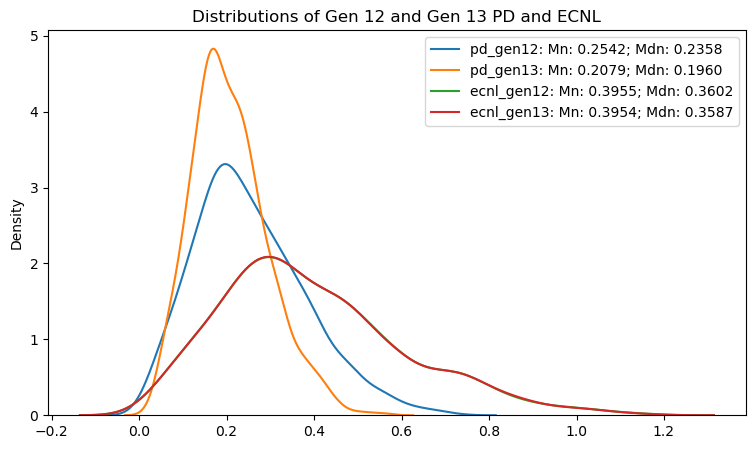

In [14]:
list_cols = [
    'pd_gen12',
    'pd_gen13',
    'ecnl_gen12',
    'ecnl_gen13',
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Gen 12 and Gen 13 PD and ECNL')
for col in tqdm(list_cols):
    flt_mn = df[col].mean()
    flt_mdn = df[col].median()
    str_label = f'{col}: Mn: {flt_mn:0.4f}; Mdn: {flt_mdn:0.4f}'
    sns.kdeplot(list(df[col]), label=str_label)
# legend
ax.legend()
# show
plt.show()

#### Create tier

In [15]:
# gen 12
df['tier_gen12'] = df['ecnl_gen12'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# gen 13
df['tier_gen13'] = df['ecnl_gen13'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# show
df

,accountid,pd_gen12,ecnl_gen12,pd_gen13,ecnl_gen13,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,tier_gen12,tier_gen13
0,8211697,0.169426,0.248733,0.116122,0.175046,NaN,0.946169,Franchise,6586.67,B,B
1,8315912,0.030895,0.045663,0.111542,0.161494,13.0,0.961424,Franchise,7885.08,A1,B
2,8323560,0.167438,0.276869,0.171425,0.304637,NaN,1.125946,Franchise,7274.08,C,C
3,8332159,0.175550,0.283977,0.305018,0.650430,13.0,1.047994,Independent,14943.06,C,Decline
4,8337838,0.045893,0.079110,0.143952,0.238451,13.0,1.268099,Franchise,4177.43,A,B
...,...,...,...,...,...,...,...,...,...,...,...
995,8472730,0.255127,0.346713,0.182745,0.328197,NaN,1.193558,Independent,6700.00,D,D
996,8472731,0.408038,0.612172,0.231619,0.446615,NaN,1.174696,Independent,4040.00,Decline,Decline
997,8472750,0.235176,0.346111,0.170825,0.303972,NaN,0.788356,Franchise,4000.00,D,C
998,8472773,0.349750,0.541301,0.262573,0.519305,NaN,1.159754,Franchise,6010.33,Decline,Decline


#### Tag approved and declined

In [16]:
# gen 12 - approved
df['approved_gen12'] = df['tier_gen12'].apply(
    lambda x: 1 if x != 'Decline' else 0,
)
# gen 13 - approved
df['approved_gen13'] = df['tier_gen13'].apply(
    lambda x: 1 if x != 'Decline' else 0,
)

# gen 12 - declined
df['declined_gen12'] = df['tier_gen12'].apply(
    lambda x: 1 if x == 'Decline' else 0,
)
# gen 13 - declined
df['declined_gen13'] = df['tier_gen13'].apply(
    lambda x: 1 if x == 'Decline' else 0,
)
# approved by both
df['approved_both'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] != 'Decline') and (x['tier_gen13'] != 'Decline') else 0,
    axis=1,
)
# declined by both
df['declined_both'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] == 'Decline') and (x['tier_gen13'] == 'Decline') else 0,
    axis=1,
)
# approved gen 12 - declined gen 13
df['approved_gen12_declined_gen13'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] != 'Decline') and (x['tier_gen13'] == 'Decline') else 0,
    axis=1,
)
# declined gen 12 - approved gen 13
df['declined_gen12_approved_gen13'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] == 'Decline') and (x['tier_gen13'] != 'Decline') else 0,
    axis=1,
)

# save
str_filename = 'df_swap_in_swap_out.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

# show
df

,accountid,pd_gen12,ecnl_gen12,pd_gen13,ecnl_gen13,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,tier_gen12,tier_gen13,approved_gen12,approved_gen13,declined_gen12,declined_gen13,approved_both,declined_both,approved_gen12_declined_gen13,declined_gen12_approved_gen13
0,8211697,0.169426,0.248733,0.116122,0.175046,NaN,0.946169,Franchise,6586.67,B,B,1,1,0,0,1,0,0,0
1,8315912,0.030895,0.045663,0.111542,0.161494,13.0,0.961424,Franchise,7885.08,A1,B,1,1,0,0,1,0,0,0
2,8323560,0.167438,0.276869,0.171425,0.304637,NaN,1.125946,Franchise,7274.08,C,C,1,1,0,0,1,0,0,0
3,8332159,0.175550,0.283977,0.305018,0.650430,13.0,1.047994,Independent,14943.06,C,Decline,1,0,0,1,0,0,1,0
4,8337838,0.045893,0.079110,0.143952,0.238451,13.0,1.268099,Franchise,4177.43,A,B,1,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8472730,0.255127,0.346713,0.182745,0.328197,NaN,1.193558,Independent,6700.00,D,D,1,1,0,0,1,0,0,0
996,8472731,0.408038,0.612172,0.231619,0.446615,NaN,1.174696,Independent,4040.00,Decline,Decline,0,0,1,1,0,1,0,0
997,8472750,0.235176,0.346111,0.170825,0.303972,NaN,0.788356,Franchise,4000.00,D,C,1,1,0,0,1,0,0,0
998,8472773,0.349750,0.541301,0.262573,0.519305,NaN,1.159754,Franchise,6010.33,Decline,Decline,0,0,1,1,0,1,0,0


#### Rates

100%|██████████| 8/8 [00:00<00:00, 12069.94it/s]


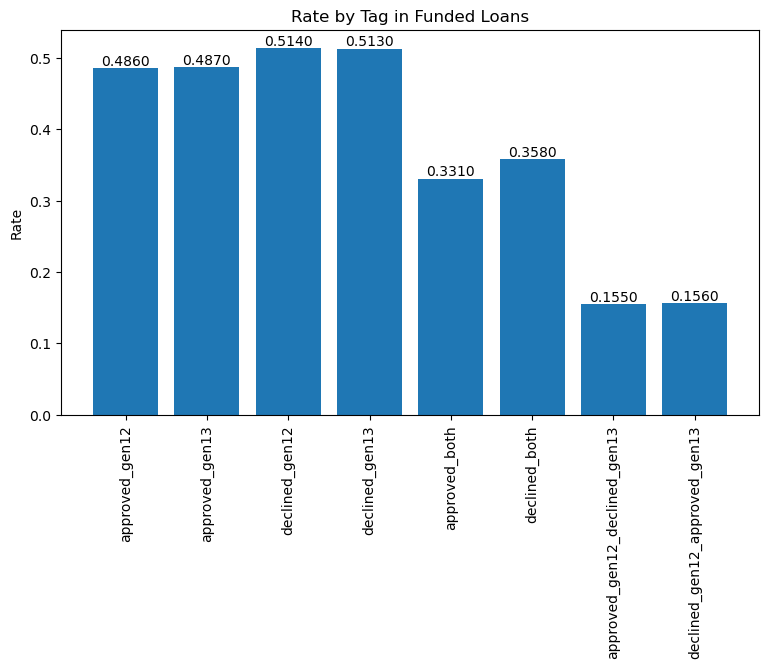

In [17]:
list_cols = [
    'approved_gen12',
    'approved_gen13',
    'declined_gen12',
    'declined_gen13',
    'approved_both',
    'declined_both',
    'approved_gen12_declined_gen13',
    'declined_gen12_approved_gen13',
]
list_dict_row = []
for col in tqdm(list_cols):
    # get mean
    flt_mean = df[col].mean()
    # row
    dict_row = {
        'column': col,
        'mean': flt_mean,
    }
    list_dict_row.append(dict_row)
df_tmp = pd.DataFrame(list_dict_row)

# plot
x = df_tmp['column']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Rate by Tag in Funded Loans')
ax.set_ylabel('Rate')
bars = ax.bar(x, df_tmp['mean'])
ax.set_xticklabels(x, rotation=90)
ax.bar_label(bars, fmt='%.4f')
# show
plt.show()

#### Get PD at mapped ECNL of 0.35

In [18]:
df_tmp = df[df['ecnl_gen13'] <= dict_tiers['D']].copy()
# get max ecnl
flt_max_ecnl = df_tmp['ecnl_gen13'].max()
# get the min pd score
flt_max_pd = df_tmp['pd_gen13'].max()
# print
print(f'At Gen 13 ECNL of {flt_max_ecnl:0.4f}, the Gen 13 PD score is {flt_max_pd:0.4f}')
print(f'So, the D threshold of Gen 13 PD is {flt_max_pd:0.4f}')

At Gen 13 ECNL of 0.3496, the Gen 13 PD score is 0.1937
So, the D threshold of Gen 13 PD is 0.1937


#### Clean-up

In [19]:
os.remove('functions_counters.py')
os.remove('functions_counters_pricing.py')